In [8]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
import time
from openai import OpenAI
from litellm import completion
from IPython.display import display
from data_prep.parser import scrub, parse
from data_prep.items import Item
from collections import Counter
from groq import Groq

load_dotenv(override=True)


True

In [7]:
groq_api_key = os.getenv("GROQ_API_KEY")
if groq_api_key:
    print("GROQ_API_KEY is set.")
else:
    print("GROQ_API_KEY is not set.")

openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
if openrouter_api_key:
    print("OPENROUTER_API_KEY is set.")
else:
    print("OPENROUTER_API_KEY is not set.")

hf_token = os.environ['HF_TOKEN']
if hf_token:
    print("HuggingFace token found.")
else:
    print("No HuggingFace token found.")

login(hf_token, add_to_git_credential=True)

#------------------------------

openrouter_url = "https://openrouter.ai/api/v1"


client_groq = Groq(api_key=groq_api_key)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


GROQ_API_KEY is set.
OPENROUTER_API_KEY is set.
HuggingFace token found.


# Load dataset from Huggingface

In [3]:
data_set = load_dataset("Shopify/product-catalogue")



In [4]:
train_ds = data_set['train']
holdout_ds = data_set['test']

split_ds = holdout_ds.train_test_split(test_size=0.5, seed=42)
test_ds = split_ds['train']
validation_ds = split_ds['test']


print(f"Number of training examples: {len(train_ds)}")
print(f"Number of test examples: {len(test_ds)}")
print(f"Number of validation examples: {len(validation_ds)}")


Number of training examples: 38631
Number of test examples: 4829
Number of validation examples: 4829


Full data point example:
{'product_title': 'Airplane Piggy Bank', 'product_description': 'The sweetest gift!', 'product_image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=785x734 at 0x141F57EC0>, 'potential_product_categories': ['Toys & Games > Toys > Flying Toys', 'Home & Garden > Decor > Piggy Banks & Money Jars', 'Toys & Games > Toys > Flying Toys > Model Aircrafts', 'Arts & Entertainment > Hobbies & Creative Arts > Arts & Crafts > Art & Crafting Materials > Pottery & Sculpting Materials > Clay & Modeling Dough > Clay > Sculpting Clay', 'Toys & Games > Toys > Beach & Sand Toys > Sand Castle Molds', 'Hardware > Tools > Dollies & Hand Trucks', 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks', 'Toys & Games > Toys > Play Vehicles > Toy Airplanes'], 'ground_truth_brand': 'Child to Cherish', 'ground_truth_is_secondhand': False, 'ground_truth_category': 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks'}
Ground truth category: Home & Garden > Hous

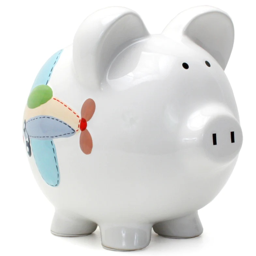

In [5]:
print("Full data point example:")
print(train_ds[0])
print("Ground truth category:", test_ds[0]["ground_truth_category"])
img = train_ds[0]["product_image"]
print(type(img))
display(img.resize((256, 256)))

## Collect the top level categories from training data

One can run the following block of code for the first time to automatically collect the cateogories from *trainning data set* . Alternatively, if the list of categories readily available, skip to the next block of code.

In [6]:
#extract top level category from the ground truth category
# def top_level_category_extractor(example):
#     top_lev = example['ground_truth_category'].split(' > ')[0]
#     return top_lev

# top_level_list = set([top_level_category_extractor(example) for example in train_ds])

In [7]:
top_level_list = {'Bundles', 'Food, Beverages & Tobacco', 'Product Add-Ons', 'Gift Cards', 'Hardware', 'Home & Garden', 'Sporting Goods', 'Electronics', 'Baby & Toddler', 'Uncategorized', 'Apparel & Accessories', 'Furniture', 'Media', 'Toys & Games', 'Religious & Ceremonial', 'Luggage & Bags', 'Cameras & Optics', 'Arts & Entertainment', 'Software', 'Office Supplies', 'Animals & Pet Supplies', 'Vehicles & Parts', 'Health & Beauty', 'Business & Industrial', 'Services'}


# Exploring data set

#### Item with longest product description

In [8]:
# longest_item_description = None
# max_len = 0
# for indx, item in enumerate(train_ds):
#     desc_len = len(item['product_description'])
#     if desc_len > max_len:
#         max_len = desc_len
#         longest_item_description = item
#         lindx = indx

# print("Length of longest product description:")
# print(len(longest_item_description['product_description']))
# print("id of the longest description item:", lindx)



Length of longest product description: 50937

id of the longest description item: 37826

In [9]:
# lengths = [len(item['product_description']) for item in train_ds]
# plt.figure(figsize=(15, 6))
# plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
# plt.xlabel('Length (chars)')
# plt.ylabel('Count')
# plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
# plt.show()

#### Item with longest product title

In [10]:
# longest_item_title = None
# max_len = 0
# for indx, item in enumerate(train_ds):
#     desc_len = len(item['product_title'])
#     if desc_len > max_len:
#         max_len = desc_len
#         longest_item_title = item
#         lindx = indx

# print("Length of longest product title:")
# print(len(longest_item_title['product_title']))
# print("id of the longest title item:", lindx)

The item with the longest product title is item 2205th in the training data.
Length of longest product title: 255

In [11]:
# lengths = [len(item['product_title']) for item in train_ds]
# plt.figure(figsize=(15, 6))
# plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
# plt.xlabel('Length (chars)')
# plt.ylabel('Count')
# plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 255, 20))
# plt.show()

# Cleaning data

In [12]:
#Data point will be scrubbed by removing barcode and converting to lowercase. This is done to remove any noise from the data and to make it easier for the model to learn from the data.
print("------------Original data point------------------:")
print(train_ds[10]['product_title'])
print(train_ds[10]['product_description'])
print("------------Scrubbed data point------------------:")
print(scrub(train_ds[10]['product_title'], train_ds[10]['product_description']))


------------Original data point------------------:
HP1044 SAUER TUROLLA PUMP
HP1044 Hydraulic pump is an original Danfoss© part produced in Germany. It has been engineered to superior standards, and is compatible with Sandvik© original specifications. HP1044 Sauer Turolla Pump is a reliable and efficient hydraulic pump designed for optimal performance in demanding industrial environments. With its precision engineering and durable construction, it delivers consistent hydraulic power to meet the needs of various applications with reliability and longevity. The unit weight is 12.5kg. HS code 8474909000. Continue exploring our store, for more PEAK quality parts!
------------Scrubbed data point------------------:
SAUER TUROLLA PUMP Hydraulic pump is an original Danfoss© part produced in Germany. It has been engineered to superior standards, and is compatible with Sandvik© original specifications. Sauer Turolla Pump is a reliable and efficient hydraulic pump designed for optimal performance

In [13]:
print(len(train_ds[37826]['product_title']))
cleaned_item = parse(train_ds[37826])
print(len(cleaned_item.category))
print(len(cleaned_item.full))


78
15
2579


In [14]:
start = time.perf_counter()
test_items = [parse(datapoint) for datapoint in tqdm(test_ds)]
test_items = [item for item in test_items if item is not None]
print(f"There are {len(test_items):,} items from {len(test_ds):,} datapoints")
end = time.perf_counter()
print(f"Elapsed: {end - start} seconds")




  0%|          | 0/4829 [00:00<?, ?it/s]

There are 4,498 items from 4,829 datapoints
Elapsed: 11.614470750006149 seconds


In [15]:
start = time.perf_counter()
train_items = [parse(datapoint) for datapoint in tqdm(train_ds)]
train_items = [item for item in train_items if item is not None]
print(f"There are {len(train_items):,} items from {len(train_ds):,} datapoints")
end = time.perf_counter()
print(f"Elapsed: {end - start} seconds")



  0%|          | 0/38631 [00:00<?, ?it/s]

There are 35,888 items from 38,631 datapoints
Elapsed: 109.05474849999882 seconds


In [16]:
start = time.perf_counter()
eval_items = [parse(datapoint) for datapoint in tqdm(validation_ds)]
eval_items = [item for item in eval_items if item is not None]
print(f"There are {len(eval_items):,} items from {len(validation_ds):,} datapoints")
end = time.perf_counter()
print(f"Elapsed: {end - start} seconds")



  0%|          | 0/4829 [00:00<?, ?it/s]

There are 4,478 items from 4,829 datapoints
Elapsed: 16.264671208991786 seconds


## Checking for duplicates to avoid data leakage

In [17]:

# Find duplicate titles across train, test, and eval sets
train_titles = set(item.full for item in train_items)
test_titles = set(item.full for item in test_items)
eval_titles = set(item.full for item in eval_items)

# Titles that appear in more than one set
duplicate_titles = (train_titles & test_titles) | (train_titles & eval_titles) | (test_titles & eval_titles)
print(f"Number of duplicate titles across sets: {len(duplicate_titles)}")
print(len(train_titles & eval_titles ))
print(len(train_titles & test_titles))
print(len(test_titles & eval_titles))

# Remove items with duplicate titles from each set
train_items = [item for item in train_items if item.full not in duplicate_titles]
test_items = [item for item in test_items if item.full not in duplicate_titles]
eval_items = [item for item in eval_items if item.full not in duplicate_titles]

print(f"After removing duplicates: Train {len(train_items)}, Test {len(test_items)}, Eval {len(eval_items)}")

Number of duplicate titles across sets: 11
6
5
0
After removing duplicates: Train 35861, Test 4493, Eval 4472


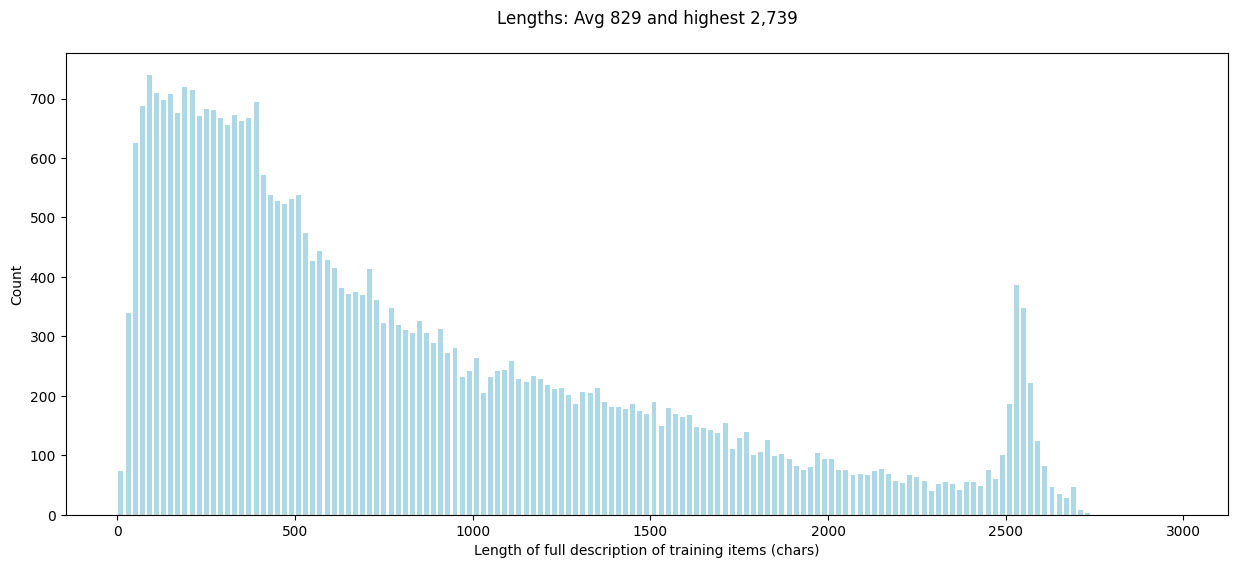

In [18]:
lengths = [len(item.full) for item in train_items]
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length of full description of training items (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 3000, 20))
plt.show()

# Create a balance data set

Counter({'Home & Garden': 5974, 'Sporting Goods': 5106, 'Arts & Entertainment': 4153, 'Hardware': 3886, 'Vehicles & Parts': 1930, 'Business & Industrial': 1812, 'Electronics': 1747, 'Health & Beauty': 1586, 'Apparel & Accessories': 1576, 'Animals & Pet Supplies': 1441, 'Food, Beverages & Tobacco': 1306, 'Furniture': 1295, 'Baby & Toddler': 907, 'Toys & Games': 897, 'Office Supplies': 895, 'Cameras & Optics': 740, 'Services': 159, 'Software': 149, 'Media': 115, 'Luggage & Bags': 114, 'Religious & Ceremonial': 49, 'Product Add-Ons': 15, 'Gift Cards': 4, 'Bundles': 3, 'Uncategorized': 2})


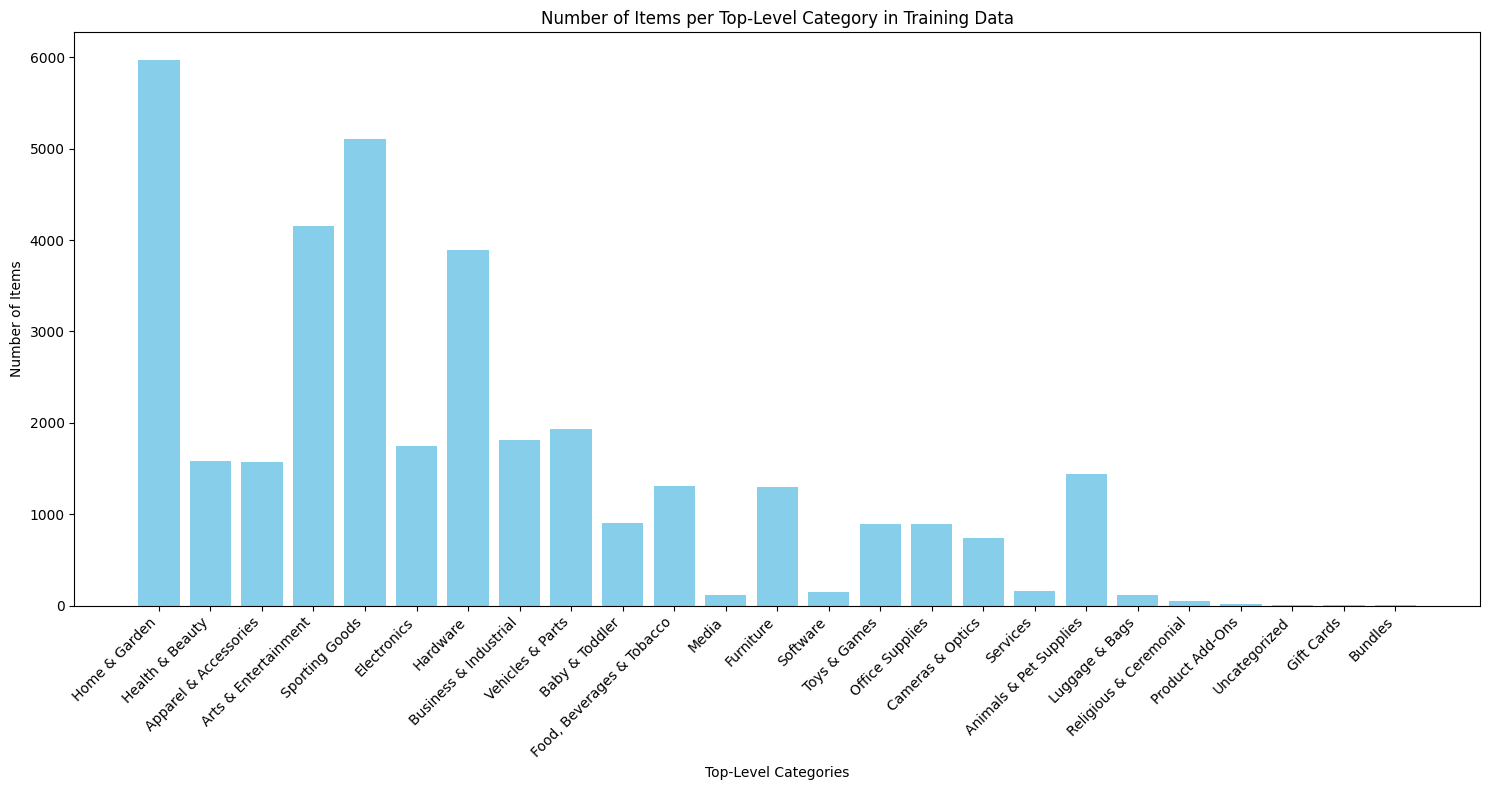

In [19]:


# Count the number of items per top-level category in train_items
category_counts = Counter(item.category for item in train_items)
print(category_counts)

# Prepare data for plotting
categories = list(category_counts.keys())
counts = list(category_counts.values())

# Create a bar plot (histogram for categorical data)
plt.figure(figsize=(15, 8))
plt.bar(categories, counts, color='skyblue')
plt.xlabel('Top-Level Categories')
plt.ylabel('Number of Items')
plt.title('Number of Items per Top-Level Category in Training Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

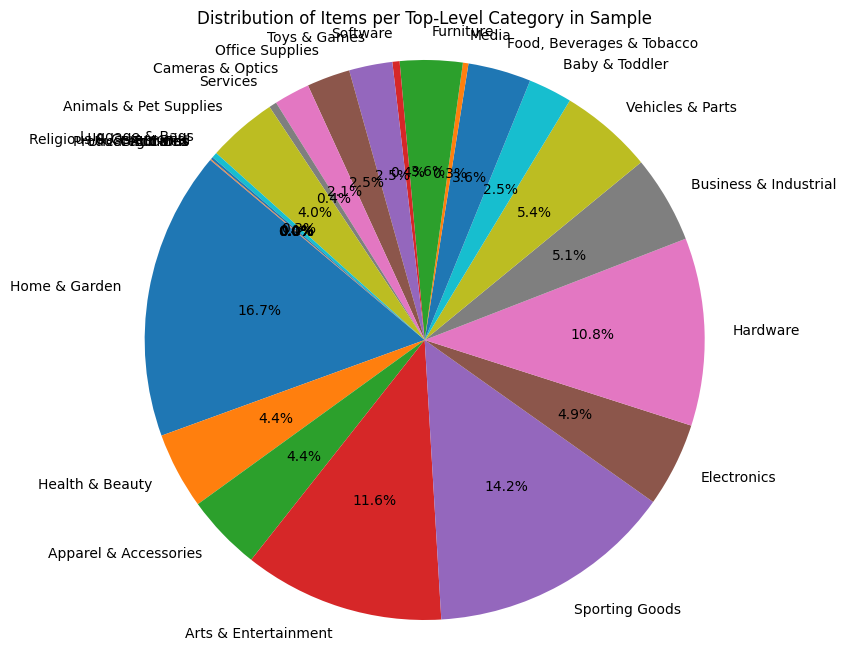

In [20]:
plt.figure(figsize=(10, 8))
plt.pie(counts, labels=categories, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Items per Top-Level Category in Sample')
plt.axis('equal')
plt.show()

In [21]:
import numpy as np

np.random.seed(42)

SIZE = 20000
p = 0.9

# Compute weights inversely proportional to category counts for balancing
weights = np.array([1 / (category_counts[item.category])**p for item in train_items])
weights /= weights.sum()  # Normalize to sum to 1

# Sample indices without replacement
idx = np.random.choice(len(train_items), size=SIZE, replace=False, p=weights)


# Create the balanced sample
sample = [train_items[i] for i in idx]


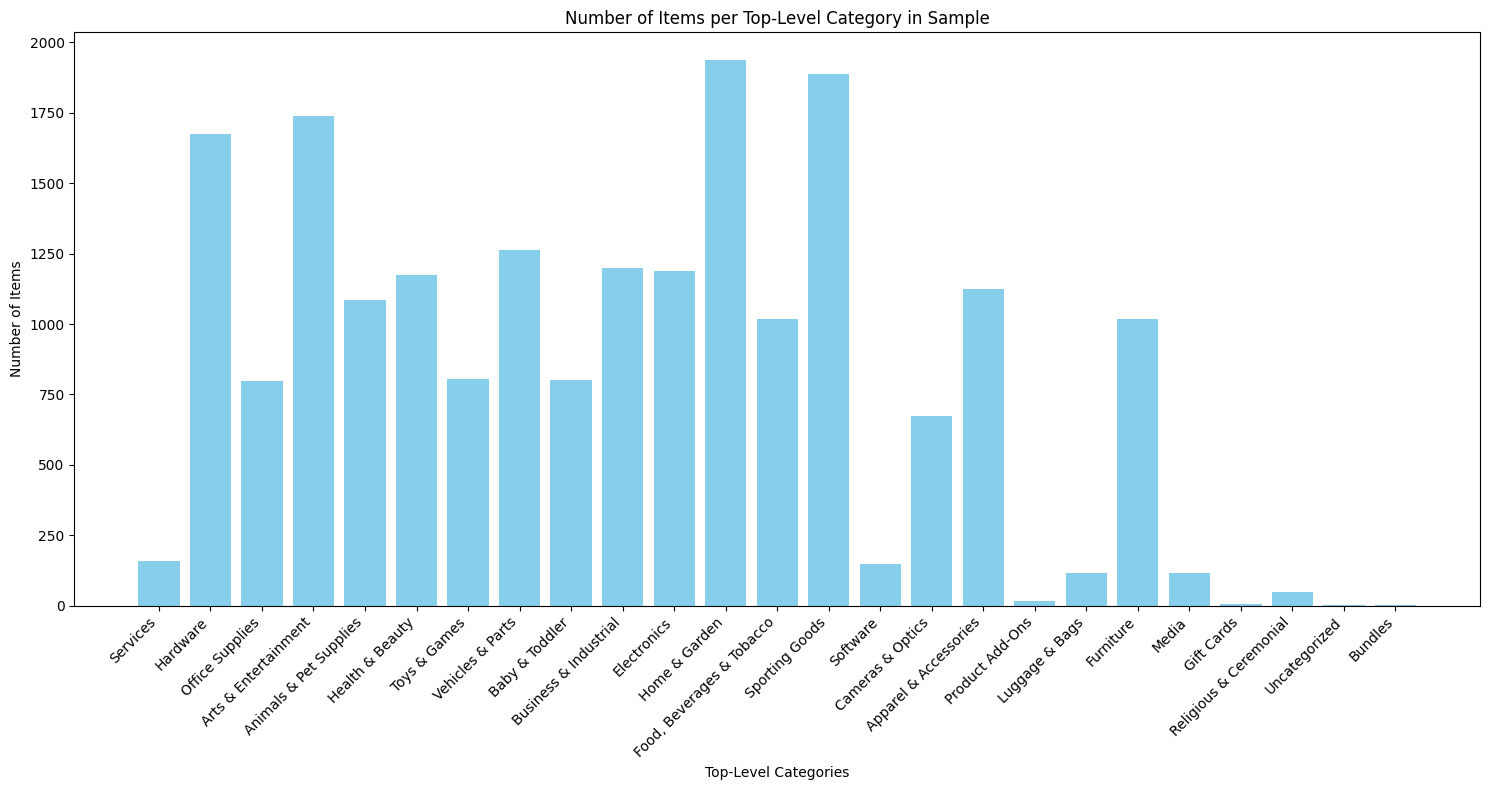

In [22]:
from collections import Counter

sample_category_counts = Counter(item.category for item in sample)
categories = list(sample_category_counts.keys())
counts = list(sample_category_counts.values())

plt.figure(figsize=(15, 8))
plt.bar(categories, counts, color='skyblue')
plt.xlabel('Top-Level Categories')
plt.ylabel('Number of Items')
plt.title('Number of Items per Top-Level Category in Sample')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

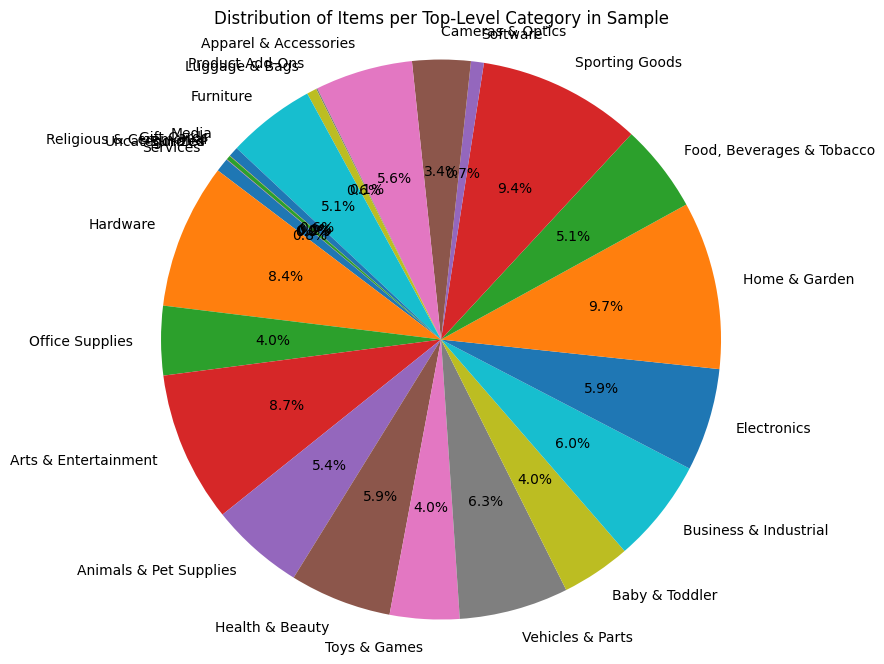

In [23]:

plt.figure(figsize=(10, 8))
plt.pie(counts, labels=categories, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Items per Top-Level Category in Sample')
plt.axis('equal')
plt.show()

# Push to HuggingFace

In [24]:
username = "leearum95"
full = f"{username}/items_raw_full_multilang"

train = sample[:]
val = eval_items[:]
test = test_items[:]


Item.push_to_hub(full, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/20 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Run one example using ChatGPT 5.1, we see that the categorization diverges from the ground truth classification.